# Statistical Methods in Imaging (SMI) Conference, 2026.
# Empowering Large Language Models with Statistics: A Practical Tutorial for Medical Imaging
**Ernest (Khashayar) Namdar, Dominik A. Deniffel, Pascal Tyrrell**

This notebook evaluates the probabilistic output from the Decoder LLM using an **unbiased** Cross-Validation approach.
For each target fold, the thresholds (J Point and B Point) are computed empirically on the *other* (training) folds, preventing data leakage.
These unbiased thresholds are then applied strictly to the target (test) fold.

The B-point method referenced here was introduced in our paper:
```bibtex
@inproceedings{namdar2024advanced,
   author = {Khashayar Namdar and Farzad Khalvati},
   booktitle = {IEEE-EMBS International Conference on Biomedical and Health Informatics},
   title = {Advanced Receiver Operating Characteristic Curve Analysis to Identify Outliers in Binary Machine Learning Classifications for Precision Medicine},
   url = {https://openreview.net/forum?id=9VCv8bLKdq},
   year = {2024}
}
```


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------
# 1. Load Data
# ------------------------
ais_path = '../../Part2_Decoder_LLM_for_Classification/data/AIS.csv'
preds_path = '../../Part2_Decoder_LLM_for_Classification/results/LM_pydantic_inference.csv'
folds_path = '../../Part1_Encoder_LLM_for_Classification/data/Folds.csv'

df_labels = pd.read_csv(ais_path)[['ID', 'Label']]
df_preds = pd.read_csv(preds_path)
df_folds = pd.read_csv(folds_path)

# Merge and drop rows where LLM probabilities are missing
df = df_labels.merge(df_preds, left_on='ID', right_on='Id').merge(df_folds, on='ID')
df = df.dropna(subset=['Prob_Yes'])


## K-Fold Unbiased Threshold Calculation

We evaluate three methods across the cross-validation folds:
1. **0.5 Threshold**: Standard binary cutoff.
2. **J Point**: Youden's J Statistic, evaluated on Training Folds.
3. **B Point**: Intersection of the B-line with the empirical ROC curve, evaluated on Training Folds.

In [4]:
# ------------------------
# 2. Calculate Thresholds
# ------------------------
all_pred_05 = []
all_pred_J = []
all_pred_B = []
all_y_true = []

# Loop over each fold
for fold_idx in sorted(df['Fold'].unique()):
    train_df = df[df['Fold'] != fold_idx]
    test_df = df[df['Fold'] == fold_idx]
    
    y_train_true = train_df['Label'].values
    y_train_prob = train_df['Prob_Yes'].values
    
    # Calculate empirical ROC on Train Folds
    fpr, tpr, thresholds = roc_curve(y_train_true, y_train_prob)
    
    # Method 2: J Point
    j_scores = tpr - fpr
    j_idx = np.argmax(j_scores)
    thresh_J = thresholds[j_idx]
    
    # Method 3: B Point
    n_pos = np.sum(y_train_true == 1)
    n_neg = np.sum(y_train_true == 0)
    m = n_neg / n_pos if n_pos > 0 else 0
    
    b_distances = np.abs(tpr + m * fpr - 1)
    b_idx = np.argmin(b_distances)
    thresh_B = thresholds[b_idx]
    
    # Static Threshold
    thresh_05 = 0.5
    
    # Apply strictly to Test Fold
    y_test_true = test_df['Label'].values
    y_test_prob = test_df['Prob_Yes'].values
    
    pred_05 = (y_test_prob >= thresh_05).astype(int)
    pred_J = (y_test_prob >= thresh_J).astype(int)
    pred_B = (y_test_prob >= thresh_B).astype(int)
    
    all_y_true.extend(y_test_true)
    all_pred_05.extend(pred_05)
    all_pred_J.extend(pred_J)
    all_pred_B.extend(pred_B)

all_y_true = np.array(all_y_true)
all_pred_05 = np.array(all_pred_05)
all_pred_J = np.array(all_pred_J)
all_pred_B = np.array(all_pred_B)


In [5]:
# ------------------------
# 3. Metrics Calculation
# ------------------------
def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0.0
    return accuracy, sensitivity, specificity, precision, f1

metrics_05 = get_metrics(all_y_true, all_pred_05)
metrics_J = get_metrics(all_y_true, all_pred_J)
metrics_B = get_metrics(all_y_true, all_pred_B)

metrics_df = pd.DataFrame(
    [metrics_05, metrics_J, metrics_B],
    columns=['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1 Score'],
    index=['Threshold=0.5', 'J Point', 'B Point']
)
display(metrics_df.round(4))


,Accuracy,Sensitivity,Specificity,Precision,F1 Score
Threshold=0.5,0.9286,0.9491,0.9252,0.6788,0.7915
J Point,0.9144,0.9884,0.9020,0.6270,0.7673
B Point,0.9382,0.7847,0.9637,0.7829,0.7838


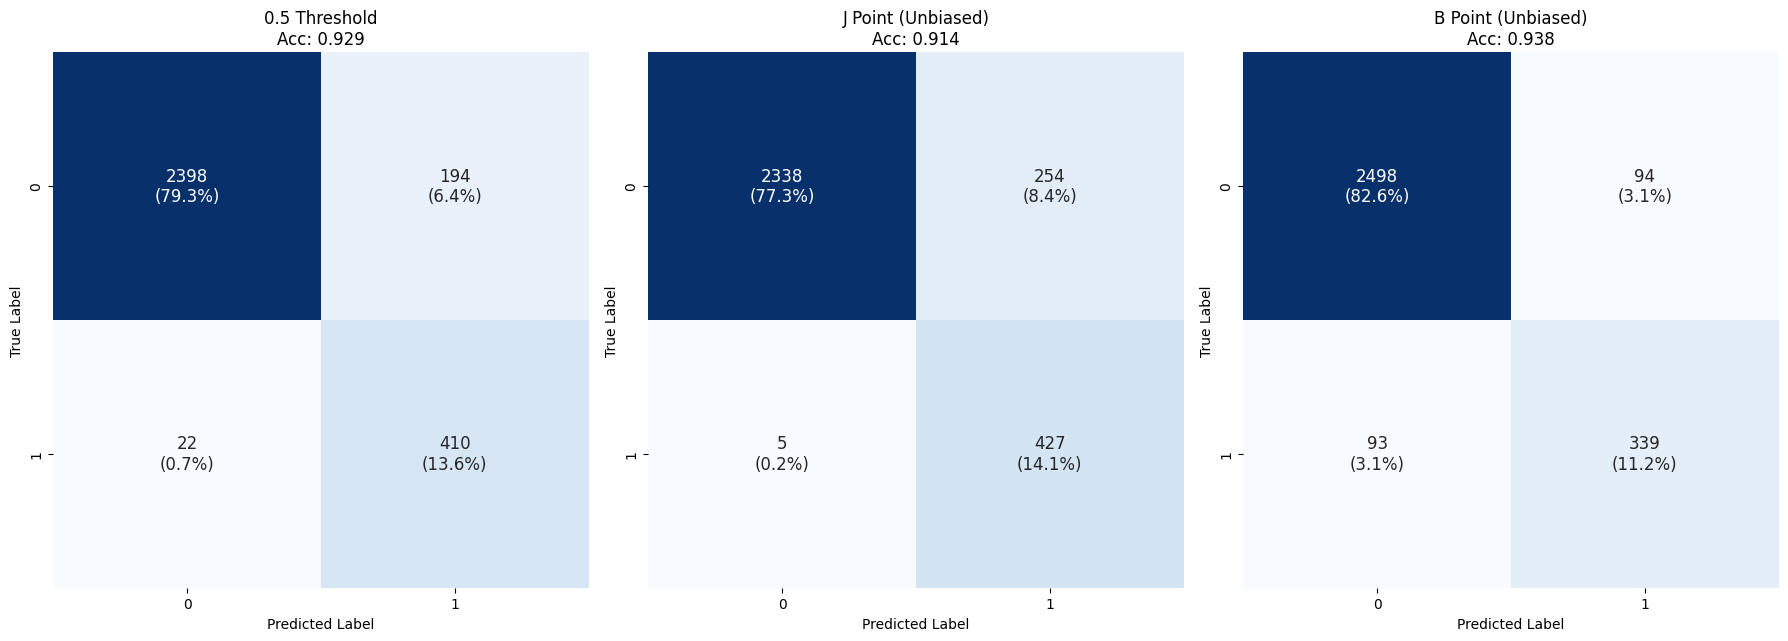

In [6]:
# ------------------------
# 4. Visualizations
# ------------------------
def plot_cm(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_perc = cm / cm.sum()
    annot = np.empty_like(cm).astype(str)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f"{cm[i, j]}\n({cm_perc[i, j]*100:.1f}%)"
            
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax, cbar=False, annot_kws={"size": 12}, square=True)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_cm(all_y_true, all_pred_05, axes[0], f'0.5 Threshold\nAcc: {metrics_05[0]:.3f}')
plot_cm(all_y_true, all_pred_J, axes[1], f'J Point (Unbiased)\nAcc: {metrics_J[0]:.3f}')
plot_cm(all_y_true, all_pred_B, axes[2], f'B Point (Unbiased)\nAcc: {metrics_B[0]:.3f}')

plt.tight_layout()
plt.show()
